# Make metallicity plots and compare with other works

In [1]:
from pathlib import Path
import sys

_here = Path.cwd().resolve()
_candidates = (_here, *_here.parents)
REPO_ROOT = next((candidate for candidate in _candidates if (candidate / "m33_pipeline").is_dir()), None)
if REPO_ROOT is None:
    raise RuntimeError(f"Could not locate repo root from {Path.cwd()}")
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from m33_pipeline.notebook_setup import prepare_notebook

REPO_ROOT = prepare_notebook(REPO_ROOT)
print(f"Notebook working directory set to: {REPO_ROOT}")

Notebook working directory set to: /Users/emmajarvis/Documents/SIGNALS/M33/PAPER1


In [2]:
import numpy as np
import pandas as pd
from pathlib import Path
from astropy.io import fits, ascii
from astropy.wcs import WCS
import astropy.units as u
import astropy.constants as c
import pyneb as pn
import matplotlib.pyplot as plt
HAS_PYNEB=True
from astropy.coordinates import SkyCoord, SkyOffsetFrame
from astropy.visualization import AsinhStretch, PercentileInterval
from skimage.segmentation import find_boundaries
from matplotlib import cm
from skimage.measure import find_contours
from matplotlib.patches import ConnectionPatch
from scipy.optimize import curve_fit
from types import SimpleNamespace
import os
import shutil
import re
import matplotlib as mpl
import seaborn as sns
try:
    from astroquery.vizier import Vizier
except ModuleNotFoundError:
    Vizier = None


from m33_pipeline.reporting import (
    add_fit_values,
    add_duplicate_region_values,
    add_halpha_flux_partition_values,
    build_catalog_number_values,
    format_value,
    load_snr_catalog,
    load_wr_catalog,
)
from m33_pipeline.planetary_nebulae import crossmatch_pne_to_hii_boundaries

plt.rcParams.update({
    "font.family": "serif",
    "mathtext.fontset": "cm",
    "axes.linewidth": 1.5,
    "xtick.direction": "in",
    "ytick.direction": "in",
})

plt.rcParams["text.usetex"] = False

plt.rc('text', usetex=False)
plt.rc('font', family='serif', size=20)

plt.rc('xtick', direction='in', top=True)
plt.rc('ytick', direction='in', right=True)
plt.rcParams['xtick.minor.visible'] = True
plt.rcParams['ytick.minor.visible'] = True

from m33_pipeline import paths



In [3]:
# Copy selected final paper figures into PAPER_PLOTS_DRAFT1.
SAVE_FOR_PAPER = True
PAPER_DRAFT_DIR = Path(globals().get('REPO_ROOT', globals().get('ROOT', Path.cwd()))) / 'PAPER_PLOTS_DRAFT1'
PAPER_FIGURE_EXPORTS = {
    'NW_zoom_with_zoi_v2.pdf': 'M33_NW_zoom_regions.pdf',
    'M33_all_fields_boundary_mosaic_SF_SNRthree_black_other_gray.png': 'M33_HaOIII_Mosaic_boundaries.png',
    'NW_00850_region_ratio_panels_dered.png': 'M33_NW_00850_ratio_panels_dered.png',
    'M33_HII_radial_gradients_multipanel_with_histograms.png': 'M33_radial_gradients_histogram.png',
    'M33_HII_Halpha_luminosity_function_correction_comparison_empirical_pdf.png': 'M33_LF_slopes.png',
    'M33_HII_L_Ha_sum_dered_vs_areaeq.png': 'M33_L_R.png',
    'M33_metallicity_calibrations_paper_multipanel.png': 'M33_metallicity_gradients_selected.png',
    'M33_metallicity_vs_logU_pressure_grid.png': 'M33_metallicity_vs_logU_pressure_grid.png',
    'M33_metallicity_calibrations_all_indicators_multipanel.png': 'M33_metallicity_calibrations_all_indicators_multipanel.png',
    'M33_literature_metallicity_comparison_4panel.png': 'M33_literature_metallicity_comparison_4panel.png',
}

def save_for_paper(source_path, draft_filename=None):
    if not SAVE_FOR_PAPER:
        return None
    source_path = Path(source_path)
    target_name = draft_filename or PAPER_FIGURE_EXPORTS.get(source_path.name)
    if target_name is None:
        return None
    import shutil
    PAPER_DRAFT_DIR.mkdir(parents=True, exist_ok=True)
    target_path = PAPER_DRAFT_DIR / target_name
    shutil.copyfile(source_path, target_path)
    print(f'Saved paper draft figure: {target_path}')
    return target_path


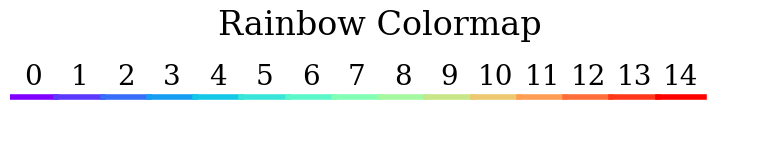

In [4]:
#make a list of 15 evenly spaced colours from the rainbow cmap to be used in all plots
cmap = plt.get_cmap('rainbow')
colors = [cmap(i) for i in np.linspace(0, 1, 15)]
#show the colours
plt.figure(figsize=(8, 2))
for i, color in enumerate(colors):
    plt.plot([i, i + 1], [0, 0], color=color, lw=4)
#label each colour with its index
for i in range(len(colors)):
    plt.text(i + 0.5, 0.1, str(i), ha='center', va='bottom')
plt.xlim(0, len(colors) + 1)
plt.ylim(-1, 1)
plt.axis('off')
plt.title('Rainbow Colormap')
plt.tight_layout()

In [5]:
# Notebook 8 uses the published machine-readable catalog as its input.
catalog_method = 'summed_map'
catalog_dig_mode = 'dig_subtracted'
# Choose which extinction-corrected flux set downstream plots should use.
# Options: 'digsub_dered' or 'nodig_dered'.
CATALOG_FLUX_VERSION = 'digsub_dered'
field_catalog_pattern = f"flux_catalogs/{catalog_method}/{catalog_dig_mode}/flux_catalog_{{FIELD}}.csv"
primary_only = True
plot_root = Path('PAPER_PLOTS') / catalog_method / catalog_dig_mode
plot_root.mkdir(parents=True, exist_ok=True)
PUBLISHED_CATALOG_PATH = plot_root / 'tables' / 'M33_emission_region_properties.csv'

cat = pd.read_csv(PUBLISHED_CATALOG_PATH)
cat_before_primary_filter = cat.copy()

# Compatibility aliases for plotting code originally written against the pipeline catalog.
if 'field' not in cat.columns and 'Field' in cat.columns:
    cat['field'] = cat['Field']
if 'region_id' not in cat.columns and 'ID' in cat.columns:
    cat['region_id'] = cat['ID']


def _augment_missing_metallicity_columns_from_pipeline_catalog(base_df):
    z_cols = [col for col in base_df.columns if col.startswith('Z_')]
    if z_cols:
        return base_df
    source_path = paths.combined_catalog_csv(catalog_method, catalog_dig_mode)
    if not source_path.exists():
        print(f'Metallicity columns missing from published catalog and pipeline catalog not found: {source_path}')
        return base_df
    source = pd.read_csv(source_path)
    key_cols = ['field', 'region_id']
    if not set(key_cols).issubset(base_df.columns) or not set(key_cols).issubset(source.columns):
        print(f'Metallicity columns missing, but cannot merge pipeline catalog because key columns are unavailable in {source_path}')
        return base_df
    missing_z_cols = [col for col in source.columns if col.startswith('Z_') and col not in base_df.columns]
    if not missing_z_cols:
        print(f'Metallicity columns missing from published catalog, and no Z_* columns found in {source_path}')
        return base_df
    merged = base_df.merge(
        source[key_cols + missing_z_cols],
        on=key_cols,
        how='left',
        validate='many_to_one',
    )
    print(f'Added {len(missing_z_cols)} metallicity columns from {source_path}')
    return merged


cat = _augment_missing_metallicity_columns_from_pipeline_catalog(cat)

if 'x' not in cat.columns:
    cat['x'] = np.nan
if 'y' not in cat.columns:
    cat['y'] = np.nan

_aliases = {
    'N_spaxels': 'npix_region',
    'R_c_pc': 'radius_areaeq_pc',
    'R_16_pc': 'radius_p16_pc',
    'R_50_pc': 'radius_p50_pc',
    'R_84_pc': 'radius_p84_pc',
    'A_V_mag': 'sum_A_V',
    'E_BV_mag': 'sum_E_BV',
    'BPT_class': 'BPT_class_sum_dered',
    'L_Halpha_raw': 'L_Ha_sum',
    'L_Halpha_dered': 'L_Ha_sum_dered_nodig',
    'L_Halpha_bgsub': 'L_Ha_sum_dered',
    'ne': 'ne_SII_cm3',
    'ne_err_minus': 'ne_SII_cm3_mc_minus',
    'ne_err_plus': 'ne_SII_cm3_mc_plus',
    'Pthermal': 'P_thermal_SII_over_k_K_cm3',
    'Pthermal_err_minus': 'P_thermal_SII_over_k_K_cm3_mc_minus',
    'Pthermal_err_plus': 'P_thermal_SII_over_k_K_cm3_mc_plus',
    'logU_KK04_err': 'logU_KK04_e',
    'has_WR': 'has_wr_in_boundary',
    'has_SNR': 'has_snr_in_boundary',
    'has_PN': 'has_pn_in_boundary',
}
for source, target in _aliases.items():
    if source in cat.columns and target not in cat.columns:
        cat[target] = cat[source]

# Compatibility defaults for columns that existed in the pipeline catalog but are
# summarized or omitted in the published paper table.
if 'ne_SII_reliable' not in cat.columns:
    ne_values = pd.to_numeric(cat['ne_SII_cm3'], errors='coerce') if 'ne_SII_cm3' in cat.columns else pd.Series(np.nan, index=cat.index)
    cat['ne_SII_reliable'] = np.isfinite(ne_values) & (ne_values > 0)

if 'n_pn_in_boundary' not in cat.columns:
    if 'has_pn_in_boundary' in cat.columns:
        cat['n_pn_in_boundary'] = cat['has_pn_in_boundary'].fillna(False).astype(bool).astype(int)
    else:
        cat['n_pn_in_boundary'] = 0

for bool_col in ['has_wr_in_boundary', 'has_snr_in_boundary', 'has_pn_in_boundary']:
    if bool_col not in cat.columns:
        cat[bool_col] = False
    else:
        cat[bool_col] = cat[bool_col].fillna(False).astype(bool)


for line in ['Halpha', 'Hbeta', '[OIII]5007', '[NII]6583', '[SII]6716', '[SII]6731', '[OII]3727']:
    for source_suffix, target_suffix in [
        ('flux_raw', 'sum_nodig'),
        ('flux_dered', 'sum_dered_nodig'),
        ('flux_bgsub', 'sum_dered'),
        ('flux_err', 'e_sum'),
        ('SNR', 'SNR_sum'),
    ]:
        source = f'{line}_{source_suffix}'
        if target_suffix == 'SNR_sum':
            target = f'SNR_{line}_sum'
        elif target_suffix == 'e_sum':
            target = f'F_{line}_e_sum'
        else:
            target = f'F_{line}_{target_suffix}'
        if source in cat.columns and target not in cat.columns:
            cat[target] = cat[source]
    dered = f'{line}_flux_dered'
    bgsub = f'{line}_flux_bgsub'
    if dered in cat.columns and f'F_{line}_sum_dered_nodig' not in cat.columns:
        cat[f'F_{line}_sum_dered_nodig'] = cat[dered]
    if bgsub in cat.columns and f'F_{line}_sum_dered_digsub' not in cat.columns:
        cat[f'F_{line}_sum_dered_digsub'] = cat[bgsub]
    chosen_dered = f'F_{line}_sum_dered_digsub' if CATALOG_FLUX_VERSION == 'digsub_dered' else f'F_{line}_sum_dered_nodig'
    if chosen_dered in cat.columns:
        cat[f'F_{line}_sum_dered'] = cat[chosen_dered]
    raw = f'{line}_flux_raw'
    if raw in cat.columns and f'F_{line}_sum' not in cat.columns:
        cat[f'F_{line}_sum'] = cat[bgsub] if bgsub in cat.columns else cat[raw]

if CATALOG_FLUX_VERSION not in {'digsub_dered', 'nodig_dered'}:
    raise ValueError(f"Unknown CATALOG_FLUX_VERSION: {CATALOG_FLUX_VERSION!r}")


def positive_halpha_snr_catalog(df, label='catalog', quiet=False):
    snr_col = next((col for col in [
        'SNR_Halpha_sum',
        'SNR_Halpha_sum_nodig',
        'Halpha_SNR',
        'Halpha_SNR_raw',
        'Halpha_SNR_obs',
    ] if col in df.columns), None)
    if snr_col is None:
        raise KeyError('Cannot apply Halpha S/N > 0 catalog cut: no Halpha S/N column found.')
    snr_values = pd.to_numeric(df[snr_col], errors='coerce')
    out = df.loc[snr_values > 0].copy().reset_index(drop=True)
    if not quiet:
        print(f'Halpha S/N > 0 filtering for {label} using {snr_col}: kept {len(out)} / {len(df)} rows.')
    return out
cat = positive_halpha_snr_catalog(cat, label='notebook 8 plotting catalog')

print(f'Notebook 8 using {CATALOG_FLUX_VERSION} fluxes for F_<line>_sum_dered plotting columns.')
if CATALOG_FLUX_VERSION == 'nodig_dered' and 'L_Ha_sum_dered_nodig' in cat.columns:
    cat['L_Ha_sum_dered'] = cat['L_Ha_sum_dered_nodig']
elif CATALOG_FLUX_VERSION == 'digsub_dered' and 'L_Halpha_bgsub' in cat.columns:
    cat['L_Ha_sum_dered'] = cat['L_Halpha_bgsub']

# Log-luminosity aliases expected by the original plotting cells.
for linear_col in ['L_Ha_sum', 'L_Ha_sum_dered_nodig', 'L_Ha_sum_dered', 'radius_areaeq_pc']:
    log_col = f'log_{linear_col}'
    if linear_col in cat.columns and log_col not in cat.columns:
        values = pd.to_numeric(cat[linear_col], errors='coerce').to_numpy(dtype=float)
        with np.errstate(divide='ignore', invalid='ignore'):
            cat[log_col] = np.where(values > 0, np.log10(values), np.nan)

if 'P_thermal_SII_over_k_K_cm3' in cat.columns and 'log_P_thermal_SII_over_k' not in cat.columns:
    values = pd.to_numeric(cat['P_thermal_SII_over_k_K_cm3'], errors='coerce').to_numpy(dtype=float)
    with np.errstate(divide='ignore', invalid='ignore'):
        cat['log_P_thermal_SII_over_k'] = np.where(values > 0, np.log10(values), np.nan)

# Compute deprojected radius if the published catalog does not include it.
if 'R_gal_kpc' not in cat.columns and {'RA_deg', 'Dec_deg'}.issubset(cat.columns):
    M33_CENTER = SkyCoord('01h33m50.9s', '+30d39m36.8s', frame='icrs')
    M33_INCL = np.deg2rad(56.0)
    M33_PA = np.deg2rad(23.0)
    M33_D_KPC = 840.0
    coords = SkyCoord(ra=cat['RA_deg'].to_numpy(dtype=float) * u.deg,
                      dec=cat['Dec_deg'].to_numpy(dtype=float) * u.deg,
                      frame='icrs')
    off = coords.transform_to(SkyOffsetFrame(origin=M33_CENTER))
    x_east_kpc = off.lon.to(u.radian).value * M33_D_KPC
    y_north_kpc = off.lat.to(u.radian).value * M33_D_KPC
    sinPA, cosPA = np.sin(M33_PA), np.cos(M33_PA)
    x_major = x_east_kpc * sinPA + y_north_kpc * cosPA
    y_minor = x_east_kpc * cosPA - y_north_kpc * sinPA
    cat['R_gal_kpc'] = np.sqrt(x_major**2 + (y_minor / np.cos(M33_INCL))**2)

if primary_only and 'primary' in cat.columns:
    cat = cat.loc[cat['primary'].fillna(True)].copy().reset_index(drop=True)

def paper_plot_path(filename, subdir=None):
    outdir = plot_root if subdir is None else plot_root / subdir
    outdir.mkdir(parents=True, exist_ok=True)
    return outdir / filename


_required_plot_columns = [
    'field', 'region_id', 'R_gal_kpc', 'sum_A_V', 'L_Ha_sum_dered',
    'log_L_Ha_sum_dered', 'ne_SII_cm3', 'ne_SII_reliable',
    'P_thermal_SII_over_k_K_cm3', 'log_P_thermal_SII_over_k',
    'radius_areaeq_pc', 'radius_p50_pc', 'log_radius_areaeq_pc',
    'has_wr_in_boundary', 'has_snr_in_boundary', 'has_pn_in_boundary',
    'n_pn_in_boundary', 'BPT_class_sum_dered',
]
_missing_plot_columns = [col for col in _required_plot_columns if col not in cat.columns]
if _missing_plot_columns:
    raise KeyError(f'Missing notebook-8 plotting compatibility columns: {_missing_plot_columns}')

print(f'Loaded published catalog from {PUBLISHED_CATALOG_PATH} with {len(cat)} rows and {len(cat.columns)} plotting-compatible columns.')


Halpha S/N > 0 filtering for notebook 8 plotting catalog using SNR_Halpha_sum: kept 5893 / 5893 rows.
Notebook 8 using digsub_dered fluxes for F_<line>_sum_dered plotting columns.
Loaded published catalog from PAPER_PLOTS/summed_map/dig_subtracted/tables/M33_emission_region_properties.csv with 5893 rows and 187 plotting-compatible columns.


In [6]:
# Load in the catalogs from Feltre et al. 2026, Alexeeva et al. 2022 and Lin et al. 2017

# Feltre et al. 2026
FELTRE_LOCAL_PATH = REPO_ROOT / "CATALOGS" / "Feltre_2026_HII_Region_catalog.tsv"


def _load_feltre_catalog():
    if Vizier is not None:
        try:
            catalog_id = "J/A+A/706/A367/catalog"
            v = Vizier(columns=["all"], row_limit=-1)
            tables = v.get_catalogs(catalog_id)
            return tables[0].to_pandas(), f"Vizier {catalog_id}"
        except Exception as exc:
            print(f"Could not load Feltre et al. 2026 from Vizier ({exc}); using local TSV.")

    if not FELTRE_LOCAL_PATH.exists():
        raise FileNotFoundError(f"Feltre local catalog not found: {FELTRE_LOCAL_PATH}")
    return pd.read_csv(FELTRE_LOCAL_PATH, sep="\t", comment="#"), str(FELTRE_LOCAL_PATH)


feltre, feltre_source = _load_feltre_catalog()

feltre = feltre.rename(columns={
    "RAJ2000": "RA",
    "DEJ2000": "Dec",
    "E(B-V)": "EBV",
    "(O/H)N2S2Ha": "OH_N2S2Ha",
    "(O/H)S": "OH_Scal",
})

# force numeric for the columns you’ll use; local TSV unit/separator rows become NaN and are dropped below.
cols_to_numeric = [
    "RA", "Dec", "EBV", "ne", "metallicity", "OH_Scal", "OH_N2S2Ha",
    "FHb", "FHa6562", "FOIII5006", "FNII6583", "FSII6716", "FSII6730",
    "e_FHb", "e_FHa6562", "e_FOIII5006", "e_FNII6583", "e_FSII6716", "e_FSII6730",
]
for col in cols_to_numeric:
    if col in feltre.columns:
        feltre[col] = pd.to_numeric(feltre[col], errors="coerce")

feltre = feltre.dropna(subset=["RA", "Dec"]).reset_index(drop=True)

# Compute deprojected galactocentric radius for the Feltre catalog using the same M33 geometry as this notebook.
M33_CENTER = SkyCoord('01h33m50.9s', '+30d39m36.8s', frame='icrs')
M33_INCL = np.deg2rad(56.0)
M33_PA = np.deg2rad(23.0)
M33_D_KPC = 840.0
feltre_coords = SkyCoord(
    ra=feltre["RA"].to_numpy(dtype=float) * u.deg,
    dec=feltre["Dec"].to_numpy(dtype=float) * u.deg,
    frame="icrs",
)
feltre_off = feltre_coords.transform_to(SkyOffsetFrame(origin=M33_CENTER))
feltre_x_east_kpc = feltre_off.lon.to(u.radian).value * M33_D_KPC
feltre_y_north_kpc = feltre_off.lat.to(u.radian).value * M33_D_KPC
sinPA, cosPA = np.sin(M33_PA), np.cos(M33_PA)
feltre_x_major = feltre_x_east_kpc * sinPA + feltre_y_north_kpc * cosPA
feltre_y_minor = feltre_x_east_kpc * cosPA - feltre_y_north_kpc * sinPA
feltre["R_gal_kpc"] = np.sqrt(feltre_x_major**2 + (feltre_y_minor / np.cos(M33_INCL))**2)

print(f"Loaded Feltre et al. 2026 catalog from {feltre_source} with {len(feltre)} regions.")


# Alexeeva et al. 2022 (ApJ, 925, 76), Table 3 from the ApJ machine-readable ASCII file.
# The table lists normalized radii R/R_25.  The tabulated R column implies
# R_25 = median(R / (R/R_25)) = 7.202 kpc, equivalent to 29.48 arcmin at D = 840 kpc.
ALEXEEVA_ASCII_PATH = REPO_ROOT / "alexeeva_2022.ascii.txt"
M33_R25_KPC_ALEXEEVA = 7.202


def _parse_alexeeva_table3(path):
    names = [
        "No", "c_Hbeta", "ne_cm3", "Te_OIII_K", "Te_NII_K", "Te_OII_K",
        "OH_N2_M2013", "OH_O3N2_M2013", "OH_direct", "NH", "NeH", "SH",
        "ClH", "ArH", "HeH", "V_kms", "sigma_Vr_kms", "R_tab_kpc", "R_R25",
    ]
    rows = []
    section = None
    for raw_line in Path(path).read_text().splitlines():
        line = raw_line.strip()
        if line == "PNe":
            section = "PN"
            continue
        if line == "H II regions":
            section = "HII"
            continue
        if not re.match(r"^\d+\s", line):
            continue
        parts = re.split(r"	+", line)
        if len(parts) != len(names):
            parts = line.split()
        if len(parts) != len(names):
            raise ValueError(f"Unexpected Alexeeva row with {len(parts)} columns: {line}")
        row = dict(zip(names, parts))
        row["object_type"] = section
        rows.append(row)

    out = pd.DataFrame(rows)
    numeric_cols = [col for col in out.columns if col != "object_type"]
    for col in numeric_cols:
        out[col] = pd.to_numeric(
            out[col].astype(str).str.replace(",", "", regex=False).replace("cdots", np.nan),
            errors="coerce",
        )
    out["R_gal_kpc_from_R25"] = out["R_R25"] * M33_R25_KPC_ALEXEEVA
    return out


alexeeva = _parse_alexeeva_table3(ALEXEEVA_ASCII_PATH)
alexeeva_hii = alexeeva.loc[alexeeva["object_type"] == "HII"].copy().reset_index(drop=True)

print(
    f"Loaded Alexeeva et al. 2022 Table 3 from {ALEXEEVA_ASCII_PATH} with "
    f"{len(alexeeva_hii)} H II regions."
)
print(
    "Alexeeva R25 conversion: "
    f"R_gal_kpc = (R/R25) * {M33_R25_KPC_ALEXEEVA:.3f} kpc."
)


# Lin et al. 2017 (ApJ, 842, 102), Table 3 from the ApJ machine-readable ASCII file.
# LIN_ASCII_PATH = REPO_ROOT / "lin_2017.ascii.txt"




Loaded Feltre et al. 2026 catalog from Vizier J/A+A/706/A367/catalog with 131 regions.
Loaded Alexeeva et al. 2022 Table 3 from /Users/emmajarvis/Documents/SIGNALS/M33/PAPER1/alexeeva_2022.ascii.txt with 95 H II regions.
Alexeeva R25 conversion: R_gal_kpc = (R/R25) * 7.202 kpc.


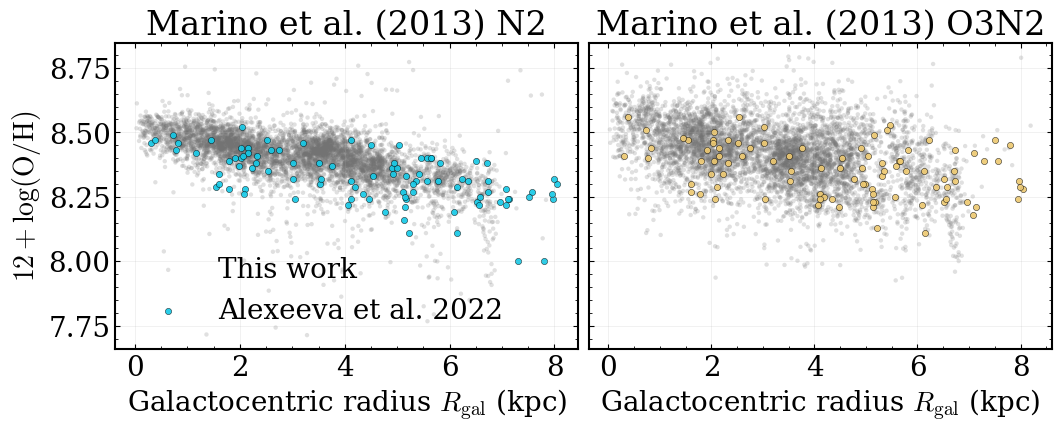

Saved PAPER_PLOTS/summed_map/dig_subtracted/literature_comparison/M33_Alexeeva2022_Marino_metallicity_vs_radius.png


In [7]:
# Compare Marino et al. (2013) N2 and O3N2 metallicities from Alexeeva et al. (2022)
# with the corresponding calibrations in this SITELLE catalog.
marino_calibrations = [
    ("OH_N2_M2013", "Z_N2_M2013", "N2", colors[4]),
    ("OH_O3N2_M2013", "Z_O3N2_M2013", "O3N2", colors[10]),
]

fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.2), sharey=True, constrained_layout=True)

for ax, (alex_col, cat_col, label, color) in zip(axes, marino_calibrations):
    cat_mask = np.isfinite(cat["R_gal_kpc"]) & np.isfinite(cat[cat_col])
    alex_mask = np.isfinite(alexeeva_hii["R_gal_kpc_from_R25"]) & np.isfinite(alexeeva_hii[alex_col])

    ax.scatter(
        cat.loc[cat_mask, "R_gal_kpc"],
        cat.loc[cat_mask, cat_col],
        s=10,
        alpha=0.22,
        color="0.45",
        edgecolor="none",
        label="This work",
    )
    ax.scatter(
        alexeeva_hii.loc[alex_mask, "R_gal_kpc_from_R25"],
        alexeeva_hii.loc[alex_mask, alex_col],
        s=20,
        alpha=0.9,
        color=color,
        edgecolor="k",
        linewidth=0.35,
        label="Alexeeva et al. 2022",
    )

    ax.set_title(f"Marino et al. (2013) {label}")
    ax.set_xlabel(r"Galactocentric radius $R_{\rm gal}$ (kpc)")
    ax.grid(alpha=0.18, linewidth=0.7)
    ax.tick_params(which="both", top=True, right=True)

axes[0].set_ylabel(r"$12 + \log({\rm O/H})$")
axes[0].legend(frameon=False, loc="best")

outpath = paper_plot_path("M33_Alexeeva2022_Marino_metallicity_vs_radius.png", subdir="literature_comparison")
fig.savefig(outpath, dpi=300, bbox_inches="tight")
save_for_paper(outpath)
plt.show()

print(f"Saved {outpath}")



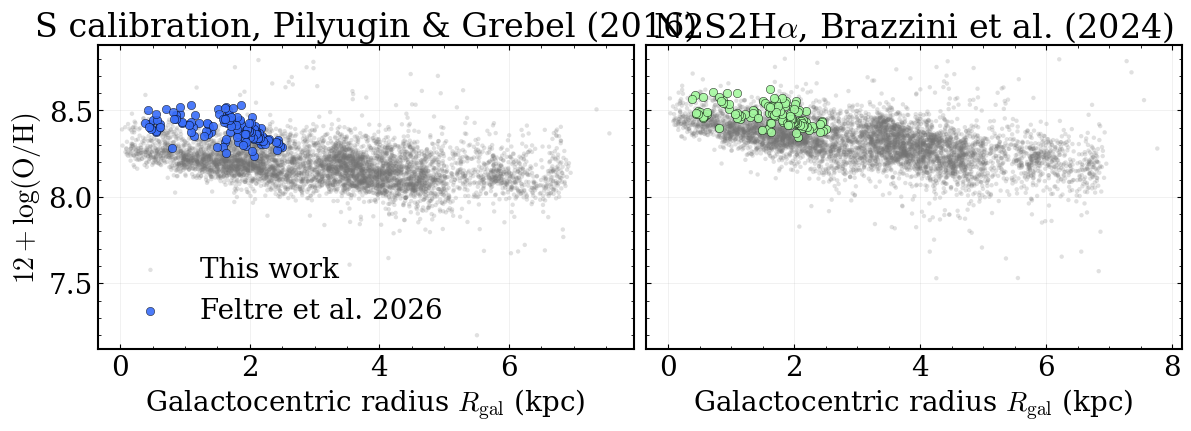

Saved PAPER_PLOTS/summed_map/dig_subtracted/literature_comparison/M33_Feltre2026_Pilyugin_Brazzini_metallicity_vs_radius.png


In [8]:
# Compare Feltre et al. (2026) metallicities with this catalog for matched calibrations.
feltre_calibrations = [
    ("OH_Scal", "Z_S_Pilyugin2016_highN2", "S calibration, Pilyugin & Grebel (2016)", colors[2]),
    ("OH_N2S2Ha", "Z_N2S2Halpha_Brazzini2024", r"N2S2H$\alpha$, Brazzini et al. (2024)", colors[8]),
]

fig, axes = plt.subplots(1, 2, figsize=(11.8, 4.2), sharey=True, constrained_layout=True)

for ax, (feltre_col, cat_col, label, color) in zip(axes, feltre_calibrations):
    cat_mask = np.isfinite(cat["R_gal_kpc"]) & np.isfinite(cat[cat_col])
    feltre_mask = np.isfinite(feltre["R_gal_kpc"]) & np.isfinite(feltre[feltre_col])

    ax.scatter(
        cat.loc[cat_mask, "R_gal_kpc"],
        cat.loc[cat_mask, cat_col],
        s=10,
        alpha=0.22,
        color="0.45",
        edgecolor="none",
        label="This work",
    )
    ax.scatter(
        feltre.loc[feltre_mask, "R_gal_kpc"],
        feltre.loc[feltre_mask, feltre_col],
        s=36,
        alpha=0.9,
        color=color,
        edgecolor="k",
        linewidth=0.35,
        label="Feltre et al. 2026",
    )

    ax.set_title(label)
    ax.set_xlabel(r"Galactocentric radius $R_{\rm gal}$ (kpc)")
    ax.grid(alpha=0.18, linewidth=0.7)
    ax.tick_params(which="both", top=True, right=True)

axes[0].set_ylabel(r"$12 + \log({\rm O/H})$")
axes[0].legend(frameon=False, loc="best")

outpath = paper_plot_path("M33_Feltre2026_Pilyugin_Brazzini_metallicity_vs_radius.png", subdir="literature_comparison")
fig.savefig(outpath, dpi=300, bbox_inches="tight")
save_for_paper(outpath)
plt.show()

print(f"Saved {outpath}")



Loaded Lin et al. 2017 tables and cross-matched 413 regions on ID/ID.
Finite Lin Marino abundances: N2=408, O3N2=380.


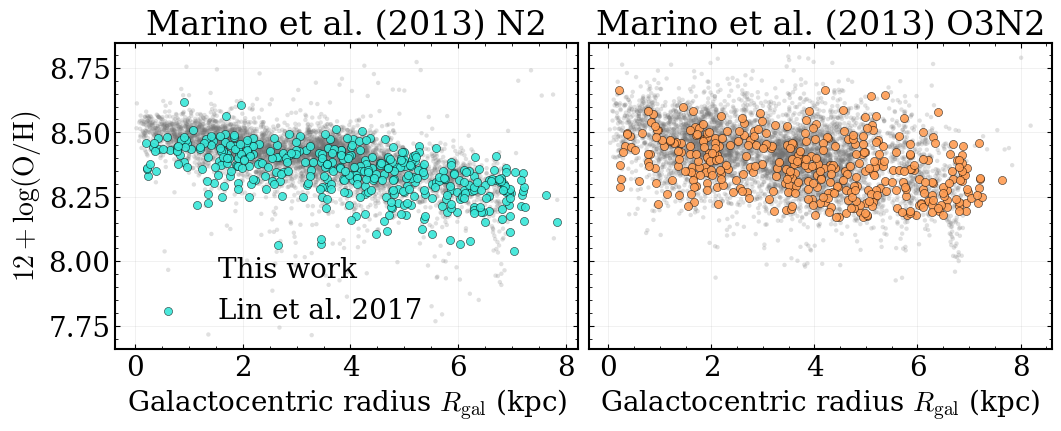

Saved PAPER_PLOTS/summed_map/dig_subtracted/literature_comparison/M33_Lin2017_Marino_metallicity_vs_radius.png


In [9]:
# Cross-match Lin et al. (2017) radius and abundance MRT tables, then compare Marino N2/O3N2.
LIN_RADIUS_TABLE_PATH = REPO_ROOT / "Lin_2017_table1.txt"
LIN_ABUNDANCE_TABLE_PATH = REPO_ROOT / "Lin_2017_table3.txt"


def _read_lin_mrt(path):
    table = ascii.read(path, format="cds").to_pandas()
    for col in table.columns:
        converted = pd.to_numeric(table[col], errors="coerce")
        if converted.notna().any():
            table[col] = converted
    return table


def _lin_id_column(df):
    for candidate in ["ID", "Seq"]:
        if candidate in df.columns:
            return candidate
    raise KeyError(f"No Lin H II-region ID column found. Available columns: {list(df.columns)}")


def _lin_radius_column(df):
    for candidate in ["R", "R_kpc", "Rgal", "R_gal_kpc"]:
        if candidate in df.columns:
            return candidate
    raise KeyError(
        "No Lin galactocentric-radius column found. "
        "Lin_2017_table1.txt appears not to be the radius/coordinate table. "
        f"Available columns: {list(df.columns)}"
    )


lin_radius = _read_lin_mrt(LIN_RADIUS_TABLE_PATH)
lin_abundance = _read_lin_mrt(LIN_ABUNDANCE_TABLE_PATH)

lin_radius_id = _lin_id_column(lin_radius)
lin_abundance_id = _lin_id_column(lin_abundance)
lin_radius_col = _lin_radius_column(lin_radius)

lin_radius_for_merge = lin_radius.rename(columns={lin_radius_id: "lin_id", lin_radius_col: "R_gal_kpc"})
lin_abundance_for_merge = lin_abundance.rename(
    columns={
        lin_abundance_id: "lin_id",
        "ZO[O3N2]": "OH_O3N2_M2013",
        "ZO[N2]": "OH_N2_M2013",
    }
)

required_lin_abundance_cols = ["lin_id", "OH_O3N2_M2013", "OH_N2_M2013"]
missing_lin_abundance_cols = [col for col in required_lin_abundance_cols if col not in lin_abundance_for_merge.columns]
if missing_lin_abundance_cols:
    raise KeyError(
        "Lin_2017_table3.txt does not include the expected Marino abundance columns: "
        f"{missing_lin_abundance_cols}. Available columns: {list(lin_abundance.columns)}"
    )

lin_2017 = lin_radius_for_merge[["lin_id", "R_gal_kpc"]].merge(
    lin_abundance_for_merge[required_lin_abundance_cols],
    on="lin_id",
    how="inner",
    validate="one_to_one",
)

for col in ["R_gal_kpc", "OH_O3N2_M2013", "OH_N2_M2013"]:
    lin_2017[col] = pd.to_numeric(lin_2017[col], errors="coerce")

print(
    f"Loaded Lin et al. 2017 tables and cross-matched {len(lin_2017)} regions "
    f"on {lin_radius_id}/{lin_abundance_id}."
)
print(
    "Finite Lin Marino abundances: "
    f"N2={np.isfinite(lin_2017['OH_N2_M2013']).sum()}, "
    f"O3N2={np.isfinite(lin_2017['OH_O3N2_M2013']).sum()}."
)

lin_marino_calibrations = [
    ("OH_N2_M2013", "Z_N2_M2013", "N2", colors[5]),
    ("OH_O3N2_M2013", "Z_O3N2_M2013", "O3N2", colors[11]),
]

fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.2), sharey=True, constrained_layout=True)

for ax, (lin_col, cat_col, label, color) in zip(axes, lin_marino_calibrations):
    cat_mask = np.isfinite(cat["R_gal_kpc"]) & np.isfinite(cat[cat_col])
    lin_mask = np.isfinite(lin_2017["R_gal_kpc"]) & np.isfinite(lin_2017[lin_col])

    ax.scatter(
        cat.loc[cat_mask, "R_gal_kpc"],
        cat.loc[cat_mask, cat_col],
        s=10,
        alpha=0.22,
        color="0.45",
        edgecolor="none",
        label="This work",
    )
    ax.scatter(
        lin_2017.loc[lin_mask, "R_gal_kpc"],
        lin_2017.loc[lin_mask, lin_col],
        s=34,
        alpha=0.9,
        color=color,
        edgecolor="k",
        linewidth=0.35,
        label="Lin et al. 2017",
    )

    ax.set_title(f"Marino et al. (2013) {label}")
    ax.set_xlabel(r"Galactocentric radius $R_{\rm gal}$ (kpc)")
    ax.grid(alpha=0.18, linewidth=0.7)
    ax.tick_params(which="both", top=True, right=True)

axes[0].set_ylabel(r"$12 + \log({\rm O/H})$")
axes[0].legend(frameon=False, loc="best")

outpath = paper_plot_path("M33_Lin2017_Marino_metallicity_vs_radius.png", subdir="literature_comparison")
fig.savefig(outpath, dpi=300, bbox_inches="tight")
save_for_paper(outpath)
plt.show()

print(f"Saved {outpath}")




In [10]:
# # now plot the Feltre S calibration and N2S2Halpha calibrations and compare with the SITELLE cataliog

# feltre_calibrations = [
#     ("OH_Scal", "Z_Scal", "S calibration", colors[6]),
#     ("OH_N2S2Ha", "Z_N2S2Ha", "N2S2Hα calibration", colors[12]),
# ]

# fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.2), sharey=True, constrained_layout=True)


Saved paper draft figure: /Users/emmajarvis/Documents/SIGNALS/M33/PAPER1/PAPER_PLOTS_DRAFT1/M33_literature_metallicity_comparison_4panel.png


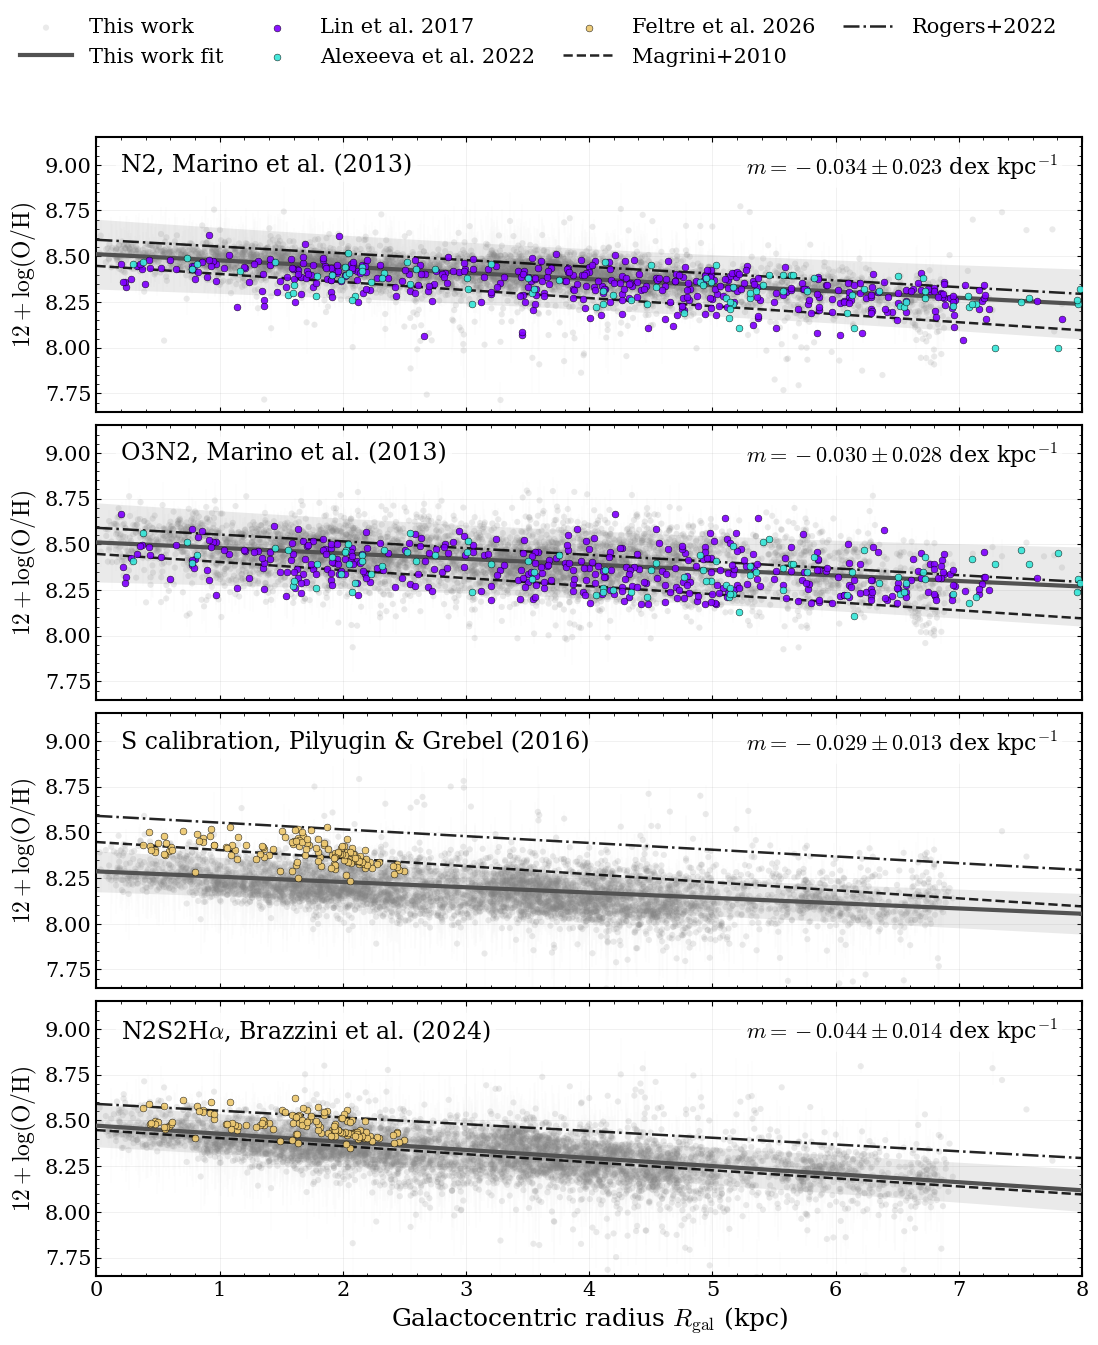

Saved PAPER_PLOTS/summed_map/dig_subtracted/literature_comparison/M33_literature_metallicity_comparison_4panel.png
N2: N=5765, slope=-0.0341 +/- 0.0234 (max of point-fit and binned/scatter-aware errors; point-fit=0.0014, binned=0.0234), intercept=8.5112 +/- 0.0052, intrinsic scatter=0.0000, median input error=0.1662, n_bins=14
O3N2: N=5659, slope=-0.0302 +/- 0.0282 (max of point-fit and binned/scatter-aware errors; point-fit=0.0016, binned=0.0282), intercept=8.5103 +/- 0.0057, intrinsic scatter=0.0000, median input error=0.1846, n_bins=14
S: N=5465, slope=-0.0290 +/- 0.0130 (max of point-fit and binned/scatter-aware errors; point-fit=0.0009, binned=0.0130), intercept=8.2864 +/- 0.0031, intrinsic scatter=0.0808, median input error=0.0559, n_bins=14
N2S2Halpha: N=5438, slope=-0.0442 +/- 0.0139 (max of point-fit and binned/scatter-aware errors; point-fit=0.0009, binned=0.0139), intercept=8.4710 +/- 0.0030, intrinsic scatter=0.0720, median input error=0.0711, n_bins=14


In [11]:
# Combined four-panel comparison against literature catalogs and direct-method gradients.
combined_literature_gradients = [
    # dict(label="Rosolowsky+2008", m=-0.027, b=8.36, ls="-"),
    dict(label="Magrini+2010", m=-0.044, b=8.447, ls="--"),
    dict(label="Rogers+2022", m=-0.037, b=8.59, ls="-."),
]

# Fill in the two NaN entries once the systematic calibration errors are chosen.
COMBINED_METALLICITY_SYSTEMATICS = {
    "Z_N2_M2013": 0.16,
    "Z_O3N2_M2013": 0.18,
    "Z_S_Pilyugin2016_highN2": np.nan,
    "Z_N2S2Halpha_Brazzini2024": np.nan,
}

CATALOG_COMPARISON_COLORS = {
    "This work": "grey",
    "Lin et al. 2017": colors[0],
    "Alexeeva et al. 2022": colors[5],
    "Feltre et al. 2026": colors[10],
}


def _combined_linear_model(x, slope, intercept):
    return slope * x + intercept


def _combined_fit_result(x, y, yerr=None, include_intrinsic_scatter=True):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    if yerr is None:
        yerr = np.full_like(y, np.nan, dtype=float)
    else:
        yerr = np.asarray(yerr, dtype=float)

    ok = np.isfinite(x) & np.isfinite(y)
    x = x[ok]
    y = y[ok]
    yerr = yerr[ok]
    if len(x) < 2:
        return None

    good_err = np.isfinite(yerr) & (yerr > 0)
    weighted = good_err.sum() >= 2
    x_fit = x[good_err] if weighted else x
    y_fit = y[good_err] if weighted else y
    sigma = yerr[good_err] if weighted else None
    if len(x_fit) < 2:
        return None

    intrinsic_scatter = np.nan
    p0 = [0.0, float(np.nanmedian(y_fit))]
    if include_intrinsic_scatter:
        try:
            initial_popt, _ = curve_fit(
                _combined_linear_model,
                x_fit,
                y_fit,
                p0=p0,
                sigma=sigma,
                absolute_sigma=weighted,
                maxfev=10000,
            )
            residuals = y_fit - _combined_linear_model(x_fit, *initial_popt)
            if len(residuals) > 2:
                raw_var = float(np.nanvar(residuals, ddof=2))
                meas_var = float(np.nanmedian(sigma**2)) if sigma is not None else 0.0
                intrinsic_scatter = np.sqrt(max(raw_var - meas_var, 0.0))
                if np.isfinite(intrinsic_scatter) and intrinsic_scatter > 0:
                    base_sigma = sigma if sigma is not None else np.zeros_like(y_fit)
                    sigma = np.sqrt(base_sigma**2 + intrinsic_scatter**2)
                    weighted = True
                    p0 = list(initial_popt)
        except Exception:
            pass

    try:
        popt, pcov = curve_fit(
            _combined_linear_model,
            x_fit,
            y_fit,
            p0=p0,
            sigma=sigma,
            absolute_sigma=weighted,
            maxfev=10000,
        )
    except Exception:
        return None

    if pcov is not None and np.all(np.isfinite(pcov)):
        perr = np.sqrt(np.diag(pcov))
    else:
        perr = [np.nan, np.nan]

    finite_yerr = yerr[np.isfinite(yerr) & (yerr > 0)]
    return SimpleNamespace(
        slope=float(popt[0]),
        intercept=float(popt[1]),
        stderr=float(perr[0]),
        intercept_stderr=float(perr[1]),
        n_points=int(len(x_fit)),
        weighted=bool(weighted),
        covariance=pcov,
        intrinsic_scatter=float(intrinsic_scatter) if np.isfinite(intrinsic_scatter) else np.nan,
        median_region_error=float(np.nanmedian(finite_yerr)) if finite_yerr.size else np.nan,
    )


def _combined_binned_fit_result(x, y, yerr=None, bins=None, min_count=20):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    if yerr is None:
        yerr = np.full_like(y, np.nan, dtype=float)
    else:
        yerr = np.asarray(yerr, dtype=float)
    if bins is None:
        bins = np.arange(fit_range[0], fit_range[1] + 0.5, 0.5)

    centers, medians, errors, counts = [], [], [], []
    for lo, hi in zip(bins[:-1], bins[1:]):
        in_bin = np.isfinite(x) & np.isfinite(y) & (x >= lo) & (x < hi)
        count = int(in_bin.sum())
        if count < min_count:
            continue
        yb = y[in_bin]
        yerrb = yerr[in_bin]
        median = float(np.nanmedian(yb))
        p16, p84 = np.nanpercentile(yb, [16, 84])
        finite_err = yerrb[np.isfinite(yerrb) & (yerrb > 0)]
        median_input_err = float(np.nanmedian(finite_err)) if finite_err.size else 0.0
        scatter_err = 0.5 * float(p84 - p16)
        centers.append(0.5 * (lo + hi))
        medians.append(median)
        # Keep the region-to-region scatter as a population term instead of
        # reducing it by sqrt(N), which would understate correlated/systematic scatter.
        errors.append(np.sqrt(scatter_err**2 + median_input_err**2))
        counts.append(count)

    centers = np.asarray(centers, dtype=float)
    medians = np.asarray(medians, dtype=float)
    errors = np.asarray(errors, dtype=float)
    if len(centers) < 3:
        return None

    try:
        popt, pcov = curve_fit(
            _combined_linear_model,
            centers,
            medians,
            sigma=errors,
            absolute_sigma=True,
            p0=[0.0, float(np.nanmedian(medians))],
            maxfev=10000,
        )
    except Exception:
        return None

    if pcov is not None and np.all(np.isfinite(pcov)):
        perr = np.sqrt(np.diag(pcov))
    else:
        perr = [np.nan, np.nan]
    return SimpleNamespace(
        slope=float(popt[0]),
        intercept=float(popt[1]),
        stderr=float(perr[0]),
        intercept_stderr=float(perr[1]),
        n_bins=int(len(centers)),
        bin_centers=centers,
        bin_medians=medians,
        bin_errors=errors,
        bin_counts=np.asarray(counts, dtype=int),
    )


def _combined_prediction_band(xgrid, fit, systematic_error=0.0, slope_error_floor=None):
    xgrid = np.asarray(xgrid, dtype=float)
    yfit = fit.slope * xgrid + fit.intercept
    pcov = getattr(fit, "covariance", None)
    if pcov is not None:
        pcov = np.asarray(pcov, dtype=float)
    if pcov is not None and pcov.shape == (2, 2) and np.all(np.isfinite(pcov)):
        design = np.column_stack([xgrid, np.ones_like(xgrid)])
        param_var = np.einsum("ij,jk,ik->i", design, pcov, design)
        param_var = np.clip(param_var, 0, np.inf)
    else:
        param_var = np.zeros_like(xgrid, dtype=float)

    if slope_error_floor is not None and np.isfinite(slope_error_floor):
        slope_err = getattr(fit, "stderr", np.nan)
        if not np.isfinite(slope_err) or slope_error_floor > slope_err:
            pivot = np.nanmedian(xgrid)
            param_var = np.maximum(param_var, (slope_error_floor * (xgrid - pivot))**2)

    terms = [param_var]
    for extra in [fit.intrinsic_scatter, fit.median_region_error, systematic_error]:
        if np.isfinite(extra) and extra > 0:
            terms.append(np.full_like(xgrid, extra**2, dtype=float))
    band_sigma = np.sqrt(np.sum(terms, axis=0))
    return yfit, yfit - band_sigma, yfit + band_sigma


def _finite_xy(df, x_col, y_col, yerr_col=None, fit_range=None):
    x = pd.to_numeric(df[x_col], errors="coerce").to_numpy(dtype=float)
    y = pd.to_numeric(df[y_col], errors="coerce").to_numpy(dtype=float)
    if yerr_col is not None and yerr_col in df.columns:
        yerr = pd.to_numeric(df[yerr_col], errors="coerce").to_numpy(dtype=float)
    else:
        yerr = np.full_like(y, np.nan, dtype=float)
    mask = np.isfinite(x) & np.isfinite(y)
    if fit_range is not None:
        mask &= (x >= fit_range[0]) & (x <= fit_range[1])
    return x[mask], y[mask], yerr[mask]


combined_indicator_specs = [
    dict(
        key="N2",
        label="N2, Marino et al. (2013)",
        our_col="Z_N2_M2013",
        our_err_col="Z_N2_M2013_e",
        literature=[
            dict(label="Lin et al. 2017", df=lin_2017, x_col="R_gal_kpc", y_col="OH_N2_M2013"),
            dict(label="Alexeeva et al. 2022", df=alexeeva_hii, x_col="R_gal_kpc_from_R25", y_col="OH_N2_M2013"),
        ],
    ),
    dict(
        key="O3N2",
        label="O3N2, Marino et al. (2013)",
        our_col="Z_O3N2_M2013",
        our_err_col="Z_O3N2_M2013_e",
        literature=[
            dict(label="Lin et al. 2017", df=lin_2017, x_col="R_gal_kpc", y_col="OH_O3N2_M2013"),
            dict(label="Alexeeva et al. 2022", df=alexeeva_hii, x_col="R_gal_kpc_from_R25", y_col="OH_O3N2_M2013"),
        ],
    ),
    dict(
        key="S",
        label="S calibration, Pilyugin & Grebel (2016)",
        our_col="Z_S_Pilyugin2016_highN2",
        our_err_col="Z_S_Pilyugin2016_highN2_e",
        literature=[
            dict(label="Feltre et al. 2026", df=feltre, x_col="R_gal_kpc", y_col="OH_Scal"),
        ],
    ),
    dict(
        key="N2S2Halpha",
        label=r"N2S2H$\alpha$, Brazzini et al. (2024)",
        our_col="Z_N2S2Halpha_Brazzini2024",
        our_err_col="Z_N2S2Halpha_Brazzini2024_e",
        literature=[
            dict(label="Feltre et al. 2026", df=feltre, x_col="R_gal_kpc", y_col="OH_N2S2Ha"),
        ],
    ),
]

fit_range = (0.0, 8.0)
xgrid = np.linspace(*fit_range, 300)
fig, axes = plt.subplots(
    nrows=4,
    ncols=1,
    figsize=(11.2, 13.8),
    sharex=True,
    sharey=True,
    constrained_layout=False,
)

legend_handles = {}
combined_fit_results = {}

for ax, spec in zip(axes, combined_indicator_specs):
    our_x, our_y, our_yerr = _finite_xy(
        cat,
        "R_gal_kpc",
        spec["our_col"],
        spec["our_err_col"],
        fit_range=fit_range,
    )
    sys_err = COMBINED_METALLICITY_SYSTEMATICS.get(spec["our_col"], np.nan)
    sys_err_for_fit = float(sys_err) if np.isfinite(sys_err) else 0.0
    finite_formal = np.isfinite(our_yerr) & (our_yerr > 0)
    yerr_for_fit = np.full_like(our_y, np.nan, dtype=float)
    if finite_formal.any() or sys_err_for_fit > 0:
        formal = np.where(finite_formal, our_yerr, 0.0)
        yerr_for_fit = np.sqrt(formal**2 + sys_err_for_fit**2)

    ax.errorbar(
        our_x[finite_formal],
        our_y[finite_formal],
        yerr=our_yerr[finite_formal],
        fmt="none",
        ecolor="0.65",
        elinewidth=0.35,
        alpha=0.045,
        zorder=1,
        rasterized=True,
    )
    
    this_work = ax.scatter(
        our_x,
        our_y,
        s=20,
        alpha=0.16,
        color=CATALOG_COMPARISON_COLORS["This work"],
        edgecolor="none",
        label="This work",
        zorder=2,
        rasterized=True,
    )
    legend_handles.setdefault("This work", this_work)

    fit = _combined_fit_result(our_x, our_y, yerr_for_fit, include_intrinsic_scatter=True)
    binned_fit = _combined_binned_fit_result(our_x, our_y, yerr_for_fit)
    if fit is not None:
        scatter_slope_err = binned_fit.stderr if binned_fit is not None else np.nan
        fit.display_stderr = np.nanmax([fit.stderr, scatter_slope_err])
        fit.scatter_stderr = scatter_slope_err
        fit.binned_slope = binned_fit.slope if binned_fit is not None else np.nan
        fit.n_bins = binned_fit.n_bins if binned_fit is not None else 0
        # The systematic calibration uncertainty is already included in yerr_for_fit.
        # The shaded band uses the larger binned/scatter-aware slope uncertainty
        # as a floor so the large catalog size does not make the slope look overprecise.
        yfit, ylo, yhi = _combined_prediction_band(
            xgrid,
            fit,
            systematic_error=0.0,
            slope_error_floor=fit.display_stderr,
        )
        ax.fill_between(xgrid, ylo, yhi, color="0.55", alpha=0.18, linewidth=0, zorder=3)
        fit_line, = ax.plot(
            xgrid,
            yfit,
            color="0.32",
            linewidth=3.0,
            label="This work fit",
            zorder=5,
        )
        legend_handles.setdefault("This work fit", fit_line)
        combined_fit_results[spec["key"]] = fit

    for lit in combined_literature_gradients:
        direct_line, = ax.plot(
            xgrid,
            lit["b"] + lit["m"] * xgrid,
            color="k",
            linestyle=lit["ls"],
            linewidth=1.8,
            alpha=0.86,
            label=lit["label"],
            zorder=4,
        )
        legend_handles.setdefault(lit["label"], direct_line)

    for dataset in spec["literature"]:
        lit_x, lit_y, _ = _finite_xy(dataset["df"], dataset["x_col"], dataset["y_col"])
        handle = ax.scatter(
            lit_x,
            lit_y,
            s=24,
            alpha=0.92,
            color=CATALOG_COMPARISON_COLORS[dataset["label"]],
            edgecolor="k",
            linewidth=0.35,
            label=dataset["label"],
            zorder=6,
        )
        legend_handles.setdefault(dataset["label"], handle)

    ax.text(
        0.025,
        0.94,
        spec["label"],
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=17,
        bbox=dict(boxstyle="round,pad=0.22", facecolor="white", edgecolor="none", alpha=0.75),
        zorder=10,
    )
    if fit is not None:
        slope_text = rf"$m = {fit.slope:.3f} \pm {fit.display_stderr:.3f}$ dex kpc$^{{-1}}$"
        ax.text(
            0.975,
            0.94,
            slope_text,
            transform=ax.transAxes,
            ha="right",
            va="top",
            fontsize=16,
            bbox=dict(boxstyle="round,pad=0.22", facecolor="white", edgecolor="none", alpha=0.75),
            zorder=10,
        )
    ax.set_ylabel(r"$12 + \log({\rm O/H})$", fontsize=17)
    ax.set_xlim(*fit_range)
    ax.set_ylim(7.65, 9.15)
    ax.grid(alpha=0.18, linewidth=0.7)
    ax.tick_params(which="both", top=True, right=True, labelsize=15)
    ax.minorticks_on()

axes[-1].set_xlabel(r"Galactocentric radius $R_{\rm gal}$ (kpc)", fontsize=18)

legend_order = [
    "This work",
    "This work fit",
    "Lin et al. 2017",
    "Alexeeva et al. 2022",
    "Feltre et al. 2026",
    # "Rosolowsky+2008",
    "Magrini+2010",
    "Rogers+2022",
]
fig.legend(
    [legend_handles[label] for label in legend_order if label in legend_handles],
    [label for label in legend_order if label in legend_handles],
    loc="upper center",
    bbox_to_anchor=(0.5, 0.995),
    ncol=4,
    frameon=False,
    fontsize=15,
    handlelength=2.5,
    columnspacing=1.35,
)
fig.subplots_adjust(top=0.895, hspace=0.05, left=0.105, right=0.985, bottom=0.07)

outpath = paper_plot_path(
    "M33_literature_metallicity_comparison_4panel.png",
    subdir="literature_comparison",
)
fig.savefig(outpath, dpi=300, bbox_inches="tight")
save_for_paper(outpath)
plt.show()

print(f"Saved {outpath}")
for spec in combined_indicator_specs:
    fit = combined_fit_results.get(spec["key"])
    if fit is None:
        continue
    print(
        f"{spec['key']}: N={fit.n_points}, slope={fit.slope:.4f} +/- {fit.display_stderr:.4f} "
        f"(max of point-fit and binned/scatter-aware errors; point-fit={fit.stderr:.4f}, "
        f"binned={fit.scatter_stderr:.4f}), "
        f"intercept={fit.intercept:.4f} +/- {fit.intercept_stderr:.4f}, "
        f"intrinsic scatter={fit.intrinsic_scatter:.4f}, median input error={fit.median_region_error:.4f}, "
        f"n_bins={fit.n_bins}"
    )
